In [78]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter, medfilt

In [79]:
# Input data folder and test number here
material = "Black_Gel"
creep_time_s = 60
recover_time_s = 600
trial_number = 2

In [80]:
loading_profile = f"_Creep_{(creep_time_s / 60):.1f}min__Recover_{(recover_time_s / 60):.1f}min"
trial_file = f"trial_{trial_number}.csv"
file_path = f"recorded_data/{material}/{loading_profile}/{trial_file}"

In [81]:
def lvdt_csv_read(file_path):
    data = pd.read_csv(file_path, skiprows=1, header=None)
    time = data.iloc[:, 0].to_numpy()
    lvdt_disp = data.iloc[:,1].to_numpy()

    t_max = time.max()
    mask = (time >= t_max - 5000) & (time <= t_max)  # Change recording to n seconds before the end
    time = time[mask]
    time = time - time[0]  # Reset time to start from zero

    lvdt_disp = lvdt_disp[mask]
    lvdt_disp = medfilt(lvdt_disp, kernel_size=7)
    lvdt_disp = lvdt_disp - lvdt_disp[0]
    return np.vstack((time, lvdt_disp)).T


In [82]:
data_1 = lvdt_csv_read(file_path)

In [83]:
plot_title = f"Material displacement under loading profile: {loading_profile}"
x_label = "Time (s)"
y_label = "LVDT Displacement (mm)"
legend_1 = f"{material}_Trial {trial_number}"

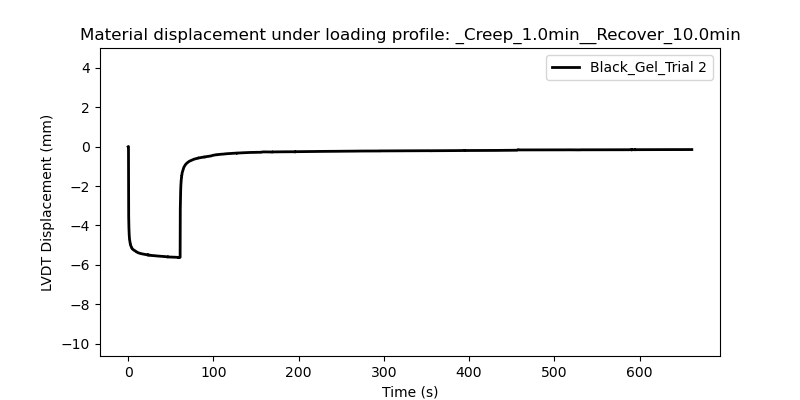

In [84]:
plt.figure(figsize=(8, 4))
plt.title(plot_title)
lw = 2
plt.plot(data_1[:,0], data_1[:,1], color = 'black', linewidth = lw, label = legend_1)
plt.ylim(min(data_1[:,1]) - 5, max(data_1[:,1]) + 5)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.legend()
# plt.savefig(f"Normal_vs_pressured_limb_long_indent.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()